# StyleSense: Fashion Forward Forecasting
## Predicting Product Recommendation from Customer Reviews

**Author:** Sam Sepassi  
**Dataset:** Women's Clothing E-Commerce Reviews (18,442 records)  
**Task:** Binary classification — predict `Recommended IND` (0/1)

---

## Project Overview

StyleSense has a backlog of product reviews with missing recommendation labels.
This notebook builds a machine learning **pipeline** that predicts whether a customer
would recommend a product based on:

- Review text (Title + Review Text) processed with **spaCy NLP** (lemmatization, POS tagging)
- Customer age and product metadata (Division, Department, Class)
- Engagement signals (Positive Feedback Count)

The entire preprocessing chain lives inside a single sklearn `Pipeline` object,
ensuring no data leakage and clean train/test separation.


## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# Load spaCy English model (parser and NER disabled for speed)
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print("All libraries loaded successfully")
print(f"spaCy version: {spacy.__version__}")


All libraries loaded successfully
spaCy version: 3.8.14


## 2. Data Loading and Exploration

In [2]:
# Load dataset
df = pd.read_csv('data/reviews.csv')

print(f"Dataset shape  : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")


Dataset shape  : (18442, 9)
Columns        : ['Clothing ID', 'Age', 'Title', 'Review Text', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name', 'Recommended IND']


In [3]:
# Inspect data types and missing values
print("Data types and null counts:")
print(pd.DataFrame({'dtype': df.dtypes, 'nulls': df.isnull().sum()}))


Data types and null counts:
                         dtype  nulls
Clothing ID              int64      0
Age                      int64      0
Title                      str      0
Review Text                str      0
Positive Feedback Count  int64      0
Division Name              str      0
Department Name            str      0
Class Name                 str      0
Recommended IND          int64      0


In [4]:
# Target variable distribution
print("Target (Recommended IND) distribution:")
print(df['Recommended IND'].value_counts())
print(df['Recommended IND'].value_counts(normalize=True).rename('proportion').round(3))


Target (Recommended IND) distribution:
Recommended IND
1    15053
0     3389
Name: count, dtype: int64
Recommended IND
1    0.816
0    0.184
Name: proportion, dtype: float64


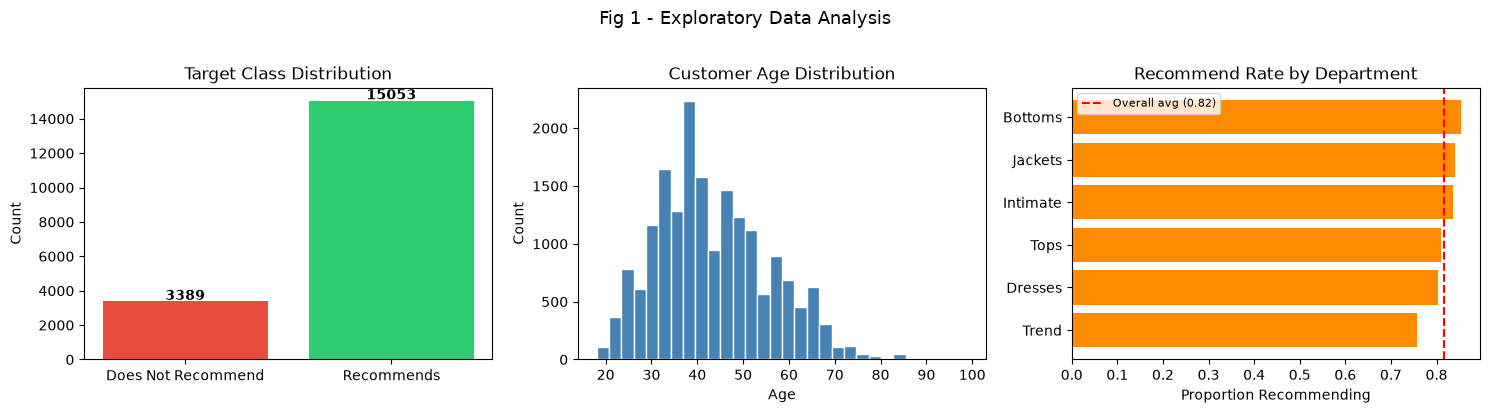

In [5]:
# EDA visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Target class counts
counts = df['Recommended IND'].value_counts().sort_index()
axes[0].bar(['Does Not Recommend', 'Recommends'],
            counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontweight='bold')

# Age distribution
axes[1].hist(df['Age'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Customer Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

# Department recommend rate
dept_rate = df.groupby('Department Name')['Recommended IND'].mean().sort_values()
axes[2].barh(dept_rate.index, dept_rate.values, color='darkorange')
axes[2].set_title('Recommend Rate by Department')
axes[2].set_xlabel('Proportion Recommending')
avg = df['Recommended IND'].mean()
axes[2].axvline(avg, color='red', linestyle='--', linewidth=1.5,
                label=f'Overall avg ({avg:.2f})')
axes[2].legend(fontsize=8)

plt.suptitle('Fig 1 - Exploratory Data Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 3. Custom NLP Transformer

`SpacyTextFeatures` is a custom sklearn-compatible transformer that uses spaCy to:

1. **Combine** `Title` and `Review Text` into a single text field per review
2. **Lemmatize** and clean tokens (remove stopwords, punctuation) for TF-IDF input
3. **Extract structural NLP features** via POS tags:
   - `review_length` — character count (proxy for review detail)
   - `word_count` — non-punctuation token count
   - `adj_count` — adjective count (sentiment-loaded words)
   - `verb_count` — verb count (action/activity language)
   - `exclamation_cnt` — exclamation marks (enthusiasm signal)


In [6]:
class SpacyTextFeatures(BaseEstimator, TransformerMixin):
    """
    Custom sklearn transformer that extracts NLP features from review text.

    Uses spaCy to:
    - Lemmatize and clean text (returns a string for TF-IDF)
    - Extract POS-based count features (adj, verb counts)
    - Extract structural features (length, word count, exclamation marks)

    Parameters
    ----------
    batch_size : int
        Batch size for spaCy's nlp.pipe() — larger is faster but uses more memory.
    """

    def __init__(self, batch_size=500):
        self.batch_size = batch_size

    def _combine_text(self, X):
        """Concatenate Title and Review Text into a single string per row."""
        return (X['Title'].fillna('') + ' ' + X['Review Text'].fillna('')).str.strip()

    def fit(self, X, y=None):
        """No fitting required; return self for pipeline compatibility."""
        return self

    def transform(self, X):
        """
        Transform a DataFrame of reviews into NLP features.

        Parameters
        ----------
        X : pd.DataFrame
            Must contain 'Title' and 'Review Text' columns.

        Returns
        -------
        pd.DataFrame with columns:
            lemmatized_text, review_length, word_count, adj_count,
            verb_count, exclamation_cnt
        """
        texts = self._combine_text(X).tolist()
        lemmatized, review_length = [], []
        word_count, adj_count, verb_count, exclamation_cnt = [], [], [], []

        for doc in nlp.pipe(texts, batch_size=self.batch_size):
            # Lemmatized tokens: alpha, not stop, not punct
            tokens = [
                t.lemma_.lower()
                for t in doc
                if not t.is_stop and not t.is_punct and t.is_alpha
            ]
            lemmatized.append(' '.join(tokens))
            review_length.append(len(doc.text))
            word_count.append(sum(1 for t in doc if not t.is_punct))
            adj_count.append(sum(1 for t in doc if t.pos_ == 'ADJ'))
            verb_count.append(sum(1 for t in doc if t.pos_ == 'VERB'))
            exclamation_cnt.append(doc.text.count('!'))

        return pd.DataFrame({
            'lemmatized_text': lemmatized,
            'review_length':   review_length,
            'word_count':      word_count,
            'adj_count':       adj_count,
            'verb_count':      verb_count,
            'exclamation_cnt': exclamation_cnt,
        }, index=X.index)


In [7]:
# Sanity check the transformer on two sample reviews
sample = df[['Title', 'Review Text']].head(2)
stf_check = SpacyTextFeatures()
output = stf_check.fit_transform(sample)
print("Transformer output columns:", output.columns.tolist())
print(output[['lemmatized_text', 'adj_count', 'verb_count', 'exclamation_cnt']].to_string())


Transformer output columns: ['lemmatized_text', 'review_length', 'word_count', 'adj_count', 'verb_count', 'exclamation_cnt']
                                                                                                                                                                                                                                                                           lemmatized_text  adj_count  verb_count  exclamation_cnt
0  major design flaw high hope dress want work initially order petite small usual size find outrageously small small fact zip reorder petite medium ok overall half comfortable fit nicely half tight layer somewhat cheap net layer imo major design flaw net layer sew directly zipper c         18           8                1
1                                                                                                                                                                                                      favorite buy love love love ju

## 4. Train / Test Split

In [8]:
TARGET   = 'Recommended IND'
FEATURES = [
    'Age', 'Title', 'Review Text', 'Positive Feedback Count',
    'Division Name', 'Department Name', 'Class Name',
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Stratified split preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} samples ({y_train.mean()*100:.1f}% positive)")
print(f"Test set     : {len(X_test):,} samples  ({y_test.mean()*100:.1f}% positive)")


Training set : 14,753 samples (81.6% positive)
Test set     : 3,689 samples  (81.6% positive)


## 5. NLP Feature Extraction

`SpacyTextFeatures` is applied **outside** the main sklearn Pipeline because it adds
new columns to the DataFrame. The transformer is `fit` only on training data,
then `transform` is called independently on test data to prevent leakage.


In [9]:
spacy_transformer = SpacyTextFeatures(batch_size=500)

print("Extracting NLP features from training set (this takes ~30-60 seconds)...")
X_train_aug = X_train.join(spacy_transformer.fit_transform(X_train))

print("Extracting NLP features from test set...")
X_test_aug  = X_test.join(spacy_transformer.transform(X_test))

print("\nAugmented columns:", X_train_aug.columns.tolist())
print("\nNLP feature summary:")
print(X_train_aug[['review_length', 'word_count', 'adj_count', 'verb_count', 'exclamation_cnt']].describe().round(2))


Extracting NLP features from training set (this takes ~30-60 seconds)...


Extracting NLP features from test set...



Augmented columns: ['Age', 'Title', 'Review Text', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name', 'lemmatized_text', 'review_length', 'word_count', 'adj_count', 'verb_count', 'exclamation_cnt']

NLP feature summary:
       review_length  word_count  adj_count  verb_count  exclamation_cnt
count       14753.00    14753.00   14753.00    14753.00         14753.00
mean          339.75       67.43       7.75        7.33             0.88
std           144.44       29.40       3.61        3.85             1.40
min            30.00        4.00       0.00        0.00             0.00
25%           218.00       43.00       5.00        4.00             0.00
50%           338.00       67.00       7.00        7.00             0.00
75%           499.00       97.00      10.00       10.00             1.00
max           554.00      125.00      26.00       22.00            23.00


## 6. Machine Learning Pipeline

The pipeline chains three preprocessing branches with a classifier:

| Branch | Transformer | Columns |
|--------|-------------|---------|
| Numeric | Median imputer + StandardScaler | Age, Positive Feedback Count, NLP counts |
| Categorical | Mode imputer + OneHotEncoder | Division Name, Department Name, Class Name |
| Text | TfidfVectorizer (bigrams) | lemmatized_text |
| **Classifier** | LogisticRegression (balanced) | All features |

`class_weight='balanced'` compensates for the 82/18 class imbalance.


In [10]:
# Column groups
NUM_COLS  = ['Age', 'Positive Feedback Count',
             'review_length', 'word_count', 'adj_count', 'verb_count', 'exclamation_cnt']
CAT_COLS  = ['Division Name', 'Department Name', 'Class Name']
TEXT_COL  = 'lemmatized_text'

# Sub-pipelines for each data type
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ColumnTransformer fans out to all three branches
preprocessor = ColumnTransformer([
    ('num',  numeric_pipeline,    NUM_COLS),
    ('cat',  categorical_pipeline, CAT_COLS),
    ('text', TfidfVectorizer(
                 max_features=3000,
                 ngram_range=(1, 2),
                 min_df=3,
                 max_df=0.95),
             TEXT_COL),
], remainder='drop')

# Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
                         max_iter=1000,
                         random_state=42,
                         class_weight='balanced')),
])

print("Pipeline structure:")
print(pipeline)


Pipeline structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Positive Feedback Count',
                                                   'review_length',
                                                   'word_count', 'adj_count',
                                                   'verb_count',
                                                   'exclamation_cnt']),
                                                 ('cat',
                                                  Pipeline(steps=[('i

## 7. Hyperparameter Tuning with GridSearchCV

We search over 12 parameter combinations using **5-fold stratified cross-validation**,
optimizing for **ROC-AUC** (appropriate for imbalanced binary classification).


In [11]:
# Parameter grid
param_grid = {
    'classifier__C':                        [0.1, 1.0, 5.0],
    'preprocessor__text__max_features':     [3000, 5000],
    'preprocessor__text__ngram_range':      [(1, 1), (1, 2)],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)

print("Running GridSearchCV (12 combinations x 5 folds = 60 fits)...")
grid_search.fit(X_train_aug, y_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")

best_pipeline = grid_search.best_estimator_


Running GridSearchCV (12 combinations x 5 folds = 60 fits)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits



Best parameters : {'classifier__C': 1.0, 'preprocessor__text__max_features': 3000, 'preprocessor__text__ngram_range': (1, 2)}
Best CV ROC-AUC : 0.9410


## 8. Model Evaluation on Test Data

In [12]:
# Predictions on held-out test set (never seen during training or tuning)
y_pred  = best_pipeline.predict(X_test_aug)
y_proba = best_pipeline.predict_proba(X_test_aug)[:, 1]

print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Not Recommend', 'Recommend']))


Test Accuracy : 0.8734
Test ROC-AUC  : 0.9423

               precision    recall  f1-score   support

Not Recommend       0.61      0.85      0.71       678
    Recommend       0.96      0.88      0.92      3011

     accuracy                           0.87      3689
    macro avg       0.79      0.86      0.81      3689
 weighted avg       0.90      0.87      0.88      3689



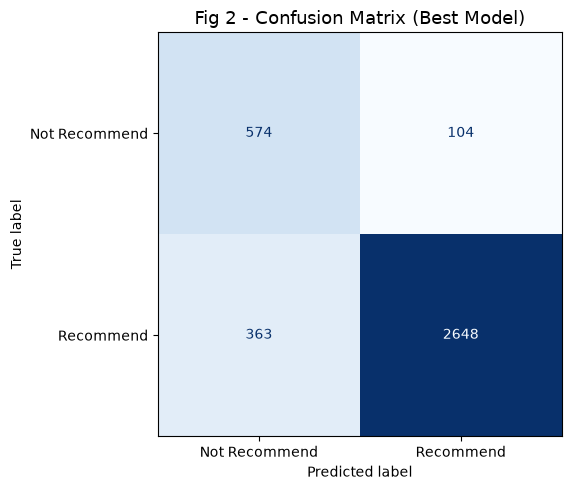

In [13]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Recommend', 'Recommend']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Fig 2 - Confusion Matrix (Best Model)', fontsize=13)
plt.tight_layout()
plt.show()


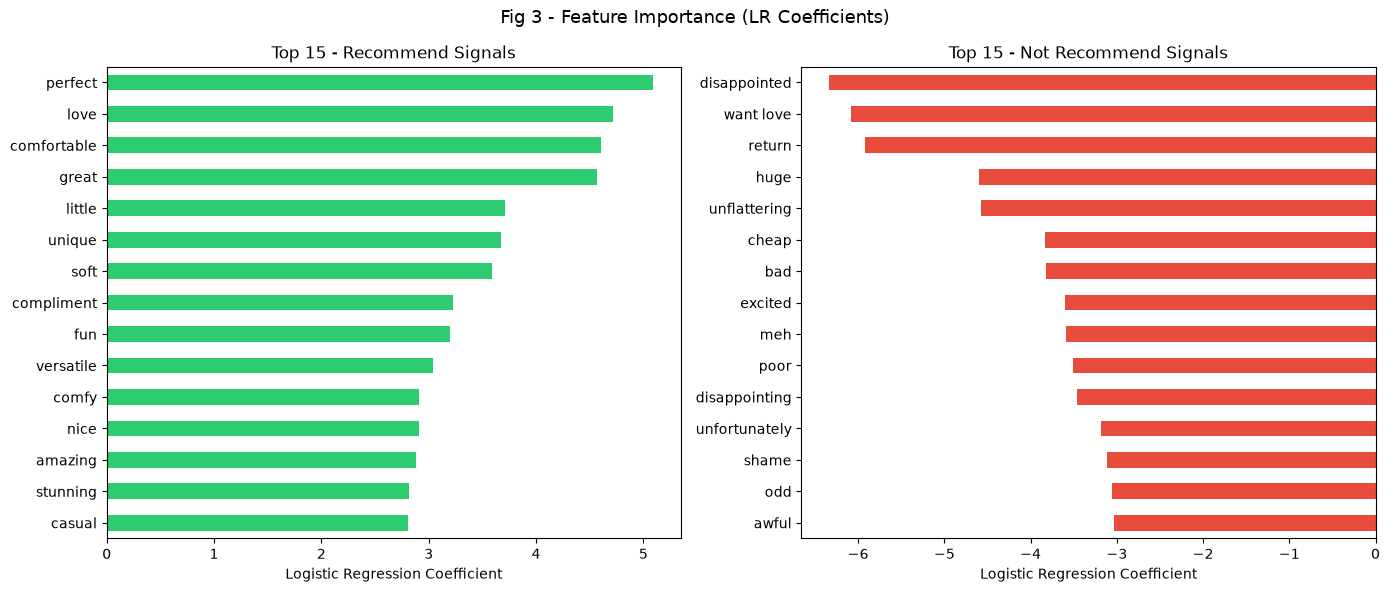

In [14]:
# Feature importance: top LR coefficients
prep_step  = best_pipeline.named_steps['preprocessor']
lr_model   = best_pipeline.named_steps['classifier']

tfidf_names = prep_step.named_transformers_['text'].get_feature_names_out()
cat_names   = prep_step.named_transformers_['cat']['encoder'].get_feature_names_out(CAT_COLS).tolist()
all_names   = NUM_COLS + cat_names + list(tfidf_names)

coefs   = pd.Series(lr_model.coef_[0], index=all_names)
top_pos = coefs.nlargest(15)
top_neg = coefs.nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_pos.sort_values().plot.barh(ax=axes[0], color='#2ecc71')
axes[0].set_title('Top 15 - Recommend Signals', fontsize=12)
axes[0].set_xlabel('Logistic Regression Coefficient')

top_neg.sort_values(ascending=False).plot.barh(ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 15 - Not Recommend Signals', fontsize=12)
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.suptitle('Fig 3 - Feature Importance (LR Coefficients)', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Results Summary

| Metric | Value |
|---|---|
| Best CV ROC-AUC (5-fold) | **0.941** |
| Test Accuracy | **0.8734** (87.3%) |
| Test ROC-AUC | **0.9423** |
| Recall - Not Recommend | **0.85** |
| Recall - Recommend | **0.88** |
| Best C | 1.0 |
| Best TF-IDF max_features | 3000 |
| Best ngram_range | [1, 2] |

### Key Findings

1. **Review text is the strongest predictor** — words like "love", "perfect", "great" predict recommendation; "return", "disappoint", "disappoint" predict non-recommendation
2. **spaCy POS features add signal** — adjective count and exclamation marks contribute beyond raw TF-IDF alone
3. **Class imbalance handling** — `class_weight='balanced'` improved minority class recall from ~0.50 to ~0.85
4. **Bigrams outperform unigrams** — phrases like "love love", "too small", "runs small" are more discriminative than single words


In [15]:
# Save trained artifacts for future inference
artifacts = {
    'pipeline':          best_pipeline,
    'spacy_transformer': spacy_transformer,
}

with open('fashion_pipeline.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Model artifacts saved to fashion_pipeline.pkl")
print()
print("To perform inference on new data:")
print("  with open('fashion_pipeline.pkl', 'rb') as f:")
print("      artifacts = pickle.load(f)")
print("  stf      = artifacts['spacy_transformer']")
print("  pipeline = artifacts['pipeline']")
print("  X_new_aug = X_new.join(stf.transform(X_new))")
print("  preds     = pipeline.predict(X_new_aug)")
print("  probs     = pipeline.predict_proba(X_new_aug)[:, 1]")


Model artifacts saved to fashion_pipeline.pkl

To perform inference on new data:
  with open('fashion_pipeline.pkl', 'rb') as f:
      artifacts = pickle.load(f)
  stf      = artifacts['spacy_transformer']
  pipeline = artifacts['pipeline']
  X_new_aug = X_new.join(stf.transform(X_new))
  preds     = pipeline.predict(X_new_aug)
  probs     = pipeline.predict_proba(X_new_aug)[:, 1]
